# Assignment 6
# Data Analytics Lab (DA5401)

#### Submitted By: Harshil Pandey (DA24C006)

In [1]:
from datasets import load_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# Task 1

Instead of seperating data into 27 files based on class, I have separeted it into 3 files based on the `partition` value. Therefore there are three files namely `train_data.tsv`, `test_data.tsv`, and `validation_data.tsv` that contain data correponding to the `partition` value of `train`, `test`, and `validation` respectively. These are tab separated files and each file has two columns `locale` and `utt` which represent the same values as discussed in the documentation.

In [2]:
langs={'af-ZA', 'da-DK', 'de-DE', 'en-US', 'es-ES', 'fr-FR', 'fi-FI', 'hu-HU', 'is-IS', 'it-IT', 
 'jv-ID', 'lv-LV', 'ms-MY', 'nb-NO', 'nl-NL', 'pl-PL', 'pt-PT', 'ro-RO', 'ru-RU', 'sl-SL', 
 'sv-SE', 'sq-AL', 'sw-KE', 'tl-PH', 'tr-TR', 'vi-VN', 'cy-GB'}

In [28]:
train_data=load_dataset('qanastek/MASSIVE', split='train')
train_df=pd.DataFrame({'locale': train_data['locale'],
                       'utt': train_data['utt']})
train_df=train_df.loc[train_df['locale'].isin(langs), :]
train_df.to_csv('train_data.tsv', sep='\t', encoding='utf-16', index=False)

In [4]:
del train_data
test_data=load_dataset('qanastek/MASSIVE', split='test')
test_df=pd.DataFrame({'locale': test_data['locale'],
                       'utt': test_data['utt']})
test_df=test_df.loc[test_df['locale'].isin(langs), :]
test_df.to_csv('test_data.tsv', sep='\t', encoding='utf-16', index=False)

In [5]:
del test_data
validation_data=load_dataset('qanastek/MASSIVE', split='validation')
validation_df=pd.DataFrame({'locale': validation_data['locale'],
                       'utt': validation_data['utt']})
validation_df=validation_df.loc[validation_df['locale'].isin(langs), :]
validation_df.to_csv('validation_data.tsv', sep='\t', encoding='utf-16', index=False)

# Task 2

All three datasets are loaded and stores in the respective variables. `X_[train/test/validation]` holds the `utt` column while `y_[train/test/validation]` holds the `locale` column that serves as our class. `pipeline` is an `sklearn.pipeline.Pipeline` instance that tokenizes the `utt` column for each data point using `TfidfVectorizer` and then passes the tokenized data to `MultinomialNB` class that trains and classifies data points using Multinomial Naive Bayes.

In [20]:
train_df=pd.read_csv('train_data.tsv', sep='\t', encoding='utf-16')
test_df=pd.read_csv('test_data.tsv', sep='\t', encoding='utf-16')
validation_df=pd.read_csv('validation_data.tsv', sep='\t', encoding='utf-16')

In [21]:
X_train, y_train=train_df['utt'], train_df['locale']
X_test, y_test=test_df['utt'], test_df['locale']
X_validation, y_validation=validation_df['utt'], validation_df['locale']

In [4]:
pipeline=Pipeline(steps=[('vectorizer', TfidfVectorizer(encoding='utf-16')),
                         ('clsf', MultinomialNB())])

In [5]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer(encoding='utf-16')),
                ('clsf', MultinomialNB())])

## Tuning the Hyperparameters of the Model.

For tuning the hyperparameters of the model, I have used `GridSearchCV`. Instead of using cross validation, the model will be evaluated on the already calculted validation data. This is achieved through the `PredefinedSplit` class. The two hyperparameters that are tuned are the `max_features` in `TfidfVectorizer` which specify how manay features are to be formed after tokenizing the data, and  `alpha` in `MultinomialNb` which specifies the degree of smoothing before training the data.  

In [6]:
X=pd.concat((X_train, X_validation), axis=0, ignore_index=True)
y=pd.concat((y_train, y_validation), ignore_index=True)
fold=np.zeros(X.shape[0])
fold[:X_train.shape[0]]=-1

In [7]:
ps=PredefinedSplit(test_fold=fold)
gscv=GridSearchCV(estimator=pipeline,
                  param_grid={'vectorizer__max_features': list(range(130000, 180000, 10000)),
                              'clsf__alpha': np.linspace(0.01, 0.5, 10)},
                  cv=ps, n_jobs=-1)
gscv.fit(X, y)

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(encoding='utf-16')),
                                       ('clsf', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'clsf__alpha': array([0.01      , 0.06444444, 0.11888889, 0.17333333, 0.22777778,
       0.28222222, 0.33666667, 0.39111111, 0.44555556, 0.5       ]),
                         'vectorizer__max_features': [130000, 140000, 150000,
                                                      160000, 170000]})

In [8]:
gscv.best_params_, gscv.best_score_

({'clsf__alpha': np.float64(0.11888888888888888),
  'vectorizer__max_features': 160000},
 np.float64(0.9850430853874041))

`model_report(model)` function take a model and prints the accuracy, precision, recall, and f1 scores on all the three subsets of data

In [9]:
def model_report(model):
    train_predictions=model.predict(X_train)
    test_predictions=model.predict(X_test)
    validation_predictions=model.predict(X_validation)

    print('Performance on Training Data:')
    print('\tAccuracy: %.3f'%(accuracy_score(y_train, train_predictions)*100))
    print('\tPrecision: %.3f'%(precision_score(y_train, train_predictions, average='macro')*100))
    print('\tRecall: %.3f'%(recall_score(y_train, train_predictions, average='macro')*100))
    print('\tF1: %.3f'%(f1_score(y_train, train_predictions, average='macro')*100), end='\n\n')

    print('Performance on Validation Data:')
    print('\tAccuracy: %.3f'%(accuracy_score(y_validation, validation_predictions)*100))
    print('\tPrecision: %.3f'%(precision_score(y_validation, validation_predictions, average='macro')*100))
    print('\tRecall: %.3f'%(recall_score(y_validation, validation_predictions, average='macro')*100))
    print('\tF1: %.3f'%(f1_score(y_validation, validation_predictions, average='macro')*100), end='\n\n')

    print('Performance on Testing Data:')
    print('\tAccuracy: %.3f'%(accuracy_score(y_test, test_predictions)*100))
    print('\tPrecision: %.3f'%(precision_score(y_test, test_predictions, average='macro')*100))
    print('\tRecall: %.3f'%(recall_score(y_test, test_predictions, average='macro')*100))
    print('\tF1: %.3f'%(f1_score(y_test, test_predictions, average='macro')*100))

We observe that the our model achieves Accuracy, Precision, Recall, and F1 scores of over 98 in all the subsets of the data.  

In [10]:
model_report(gscv)

Performance on Training Data:
	Accuracy: 99.295
	Precision: 99.298
	Recall: 99.295
	F1: 99.296

Performance on Validation Data:
	Accuracy: 99.191
	Precision: 99.196
	Recall: 99.191
	F1: 99.192

Performance on Testing Data:
	Accuracy: 98.537
	Precision: 98.585
	Recall: 98.537
	F1: 98.548


# Task 3

Instead of concatenating files, I have grouped the data based on the continents accordingly.

In [22]:
groups={'af-ZA': 'Africa', 'cy-GB': 'Europe', 'da-DK': 'Europe', 'de-DE': 'Europe',
        'en-US': 'North America', 'es-ES': 'Europe', 'fi-FI': 'Europe', 'fr-FR': 'Europe',
        'hu-HU': 'Europe', 'is-IS': 'Europe', 'it-IT': 'Europe', 'jv-ID': 'Asia',
        'lv-LV': 'Europe', 'ms-MY': 'Asia', 'nb-NO': 'Europe', 'nl-NL': 'Europe',
        'pl-PL': 'Europe', 'pt-PT': 'Europe', 'ro-RO': 'Europe', 'ru-RU': 'Asia',
        'sl-SL': 'Europe', 'sq-AL': 'Europe', 'sv-SE': 'Europe', 'sw-KE': 'Africa',
        'tl-PH': 'Asia', 'tr-TR': 'Asia', 'vi-VN': 'Asia'}

y_train=y_train.apply(lambda x: groups[x])
y_test=y_test.apply(lambda x: groups[x])
y_validation=y_validation.apply(lambda x: groups[x])

Tokenizing the data produces more than 150000 feautures. Due to memory contraints, the whole tokenized dataset cannot be used for training, as `LinearDiscriminantAnalysis` and `QuadraticDiscriminantAnalysis` have higher memory requirements. To tackle this issue, the data has to be transformed to a lower dimension and then passed to our classifiers. For this transformation I have used a pipeline that 
1) Transforms the data into 10000 most important tokens using `TfidfVectorizer`.
2) Passes the transformed data from Step1 to `PCA` to reduce the dimensionality of the dataset to 500 most important componets.

`PCA` was chosen as it can deal with sparse representation of the data which saves memory.

In [24]:
trans=Pipeline(steps=[('vectorizer', TfidfVectorizer(encoding='utf-16', max_features=10000)),
                      ('pca', PCA(n_components=500))])
X_train=trans.fit_transform(X_train, y_train)
X_test=trans.transform(X_test)
X_validation=trans.transform(X_validation)

`LDA_QDA` is the class that takes `qda_ratio` as the parameter that represents the trade-off of LDA and QDA. The `qda_ratio` value has to be between the range $[0, 1]$. 
* if the value is 0, it means that only LDA will be used for prediction.
* if the value is 1, it means that only QDA will be used for prediction.
* in other cases, both LDA and QDA will be trained on the data. The prediction is determined in the following manner:
    * For each data point, probabilities for it being classified as a  class is predicted using both the models. Let the probablity of $i^{th}$ data point being classified as the $j^{th}$ class given by both the methods be: 
    $\\ p^{lda}_{ij}$ and $p^{qda}_{ij}$ corresponding to probablities predicted by LDA and QDA respectively. 
    * In our case $j$ can take one of four values given by $\{Africa, \ North \ America, \ Europe, \ Asia\}$
    * Now the overall probability of the $i^{th}$ data being classified as the $j^{th}$ class is given by the formula: $\\(1-\lambda)p^{lda}_{ij} + \lambda p^{qda}_{ij}$, where $\lambda$  is same as `qda_ratio` described above.
    * The predicted class for $i^{th}$ data point is that class which has the maximum overall probality among all the classes.


In [25]:
class LDA_QDA(BaseEstimator, ClassifierMixin):
    def __init__(self, qda_ratio=0):
        self.qda_ratio=qda_ratio
        self.lda=LinearDiscriminantAnalysis()
        self.qda=QuadraticDiscriminantAnalysis()
        self._is_fitted=False
    
    def fit(self, X, y):
        if self.qda_ratio==0:
            self.lda.fit(X, y)
        elif self.qda_ratio==1:
            self.qda.fit(X, y)
        else:
            self.lda.fit(X, y)
            self.qda.fit(X, y)
        self._is_fitted=True
        return self
    
    def predict(self, X):
        return self.predict_change_tradeoff(X, self.qda_ratio)

    def predict_change_tradeoff(self, X, qda_ratio):
        if qda_ratio==0:
            return self.lda.predict(X)
        elif qda_ratio==1:
            return self.qda.predict(X)
        else:
            lda_proba=self.lda.predict_proba(X)
            qda_proba=self.qda.predict_proba(X)
            proba=(1-qda_ratio)*lda_proba + qda_ratio*qda_proba
            return  self.lda.classes_[proba.argmax(axis=1)]

    def __sklearn_is_fitted__(self):
        return self._is_fitted

In [26]:
clsf3=LDA_QDA(0.5)
clsf3.fit(X_train, y_train)

LDA_QDA(qda_ratio=0.5)

In [27]:
model_report(clsf3)

Performance on Training Data:
	Accuracy: 95.402
	Precision: 85.378
	Recall: 97.079
	F1: 89.777

Performance on Validation Data:
	Accuracy: 94.981
	Precision: 84.439
	Recall: 96.640
	F1: 88.904

Performance on Testing Data:
	Accuracy: 95.097
	Precision: 84.709
	Recall: 96.796
	F1: 89.099


In [ ]:
lda_proba=clsf3.lda.predict_proba(X_test)
qda_proba=clsf3.qda.predict_proba(X_test)

Confusuion Matrix For LDA

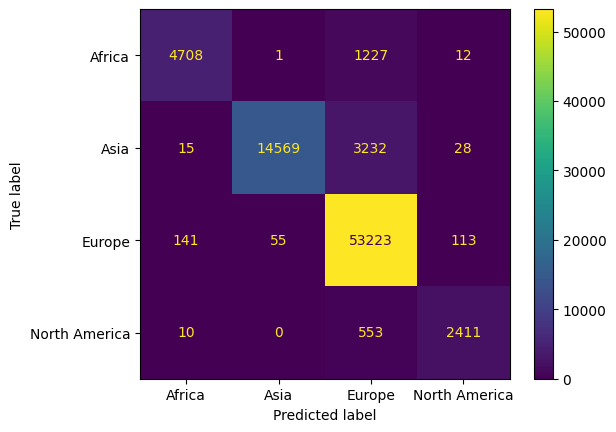

In [40]:
predictions_lda=clsf3.lda.classes_[lda_proba.argmax(axis=1)]
ConfusionMatrixDisplay.from_predictions(y_test, predictions_lda, display_labels=clsf3.lda.classes_);

Confusion Matrix for QDA

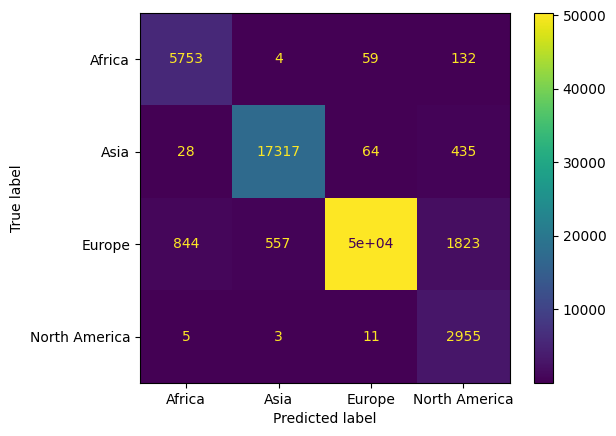

In [42]:
predictions_qda=clsf3.lda.classes_[qda_proba.argmax(axis=1)]
ConfusionMatrixDisplay.from_predictions(y_test, predictions_qda, display_labels=clsf3.lda.classes_);

From the above metrics we observe that QDA has better performance than LDA as it is able distinguish between classes better. LDA is not able to correctly predict the minority classes like Africa and North America as it has lower recall for these classes.

Let us visualize the effect of $\lambda$/`qda_ratio` on the test F1-Score

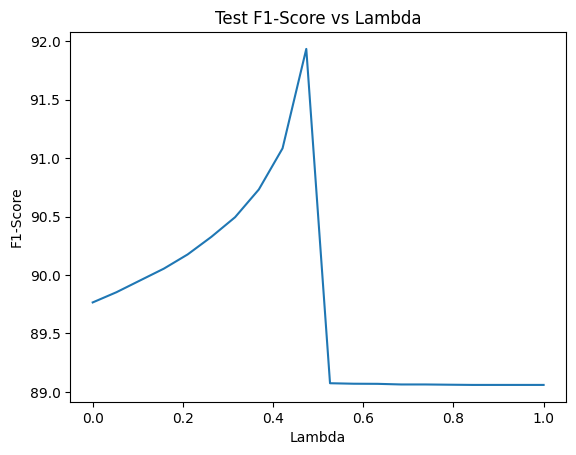

In [59]:
ratios=np.linspace(0, 1, 20)
scores=[]
for qda_ratio in ratios:
    proba=(1-qda_ratio)*lda_proba + qda_ratio*qda_proba
    predictions=clsf3.lda.classes_[proba.argmax(axis=1)]
    scores.append(f1_score(y_test, predictions, average='macro')*100)
    # scores.append(accuracy_score(y_test, predictions)*100)
plt.plot(ratios, scores)
plt.xlabel('Lambda')
plt.ylabel('F1-Score')
plt.title('Test F1-Score vs Lambda');